Testning of moving everything to work on a vectorised input of magnetic fields
- Brief testing for things like transition frequency calculations shows a 10x speedup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qil_helpers.Ben.General as Ben
import qil_helpers.Ben.Holeburning_analysis as HBA

#from qil_SpinHamiltonian.spin_hamiltonian import hamilFromYAML,eachElemFunc,transitionPixelPlot
import qil_SpinHamiltonian.spin_hamiltonian as spin
import qil_SpinHamiltonian.search as spinSearch

import matplotlib.colors as clr
import glob
import scipy.signal as sig
import re
import scipy as sp
import os
import pandas as pd
from copy import copy
from scipy import integrate,optimize

from IPython.display import display, Latex
from scipy.spatial.transform import Rotation

import plotly.graph_objects as go


In [2]:
path="C:/Users/neb16/Documents/Uni/PHD/Experiments/Simulations/Spin_Hamiltonian/spin_hamiltonian/ion_params/"
gnd="Yb_CaWO.yml"
ground=spin.hamilFromYAML(path+gnd)



{'Spin': {'Espin': '1/2', 'Ispin': '1/2'}, 'Hyperfine': {'A': 'np.matrix([[3.0819,0,0],[0,3.0819,0],[0,0,-0.789]])*1e9*h', 'A_rot': 'np.array([0,0,0])'}, 'E_Zeeman': {'g': 'np.matrix([[3.916,0,0],[0,3.916,0],[0,0,-1.446]])', 'g_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '0.987'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}


In [3]:
pts=50
r=1E-4
thetas,phis=np.meshgrid(np.linspace(0,np.pi,pts),np.linspace(0,2*np.pi,pts))
x=(r*np.sin(thetas)*np.cos(phis)).flatten()
y=(r*np.sin(thetas)*np.sin(phis)).flatten()
z=(r*np.cos(thetas)).flatten()
vec=np.vstack([x,y,z])
Bs=vec


In [4]:
# Transition calulations
HZ=spin.muB*Bs.T@ground.gE@ground.S.T
HZ=np.array(HZ.T).reshape((ground.Edim,ground.Edim,-1))
I=np.eye((ground.dim)//ground.Edim)[:,:,np.newaxis]#1,axis=2)
HZ = np.kron(HZ,I)
HG=np.array(ground.H)[:,:,np.newaxis]+HZ
#E,V=ground.getEigFreq(HG.T)
E,V=np.linalg.eigh(HG.T)
E = -1*np.real(E)
print(E.shape)
ind = np.argsort(E) #sort E into increasing values of eigen values
print(ind.shape)
E=np.take_along_axis(E,ind,axis=-1)
print(V.shape)
V=np.take_along_axis(V,ind[:,np.newaxis,:],axis=-1)
print(V.shape)

E=E/(spin.h*1E9)

#plr.plo

(2500, 4)
(2500, 4)
(2500, 4, 4)
(2500, 4, 4)


In [13]:
#generate a set of fields from zero to 100mT
Bz=np.linspace(0,200*1E-3,200)
#Unit vector along z
uvec=np.matrix([0,0,1]).T

#convert it to a vector along the our axis
B=uvec*Bz
H=ground.dynamicH(B)
F,V=ground.getEigFreq(H)

Vi=V[10,:,0]
Hi=H[10,...]/(spin.h*1E9)
Fi=F[10,0]
print(Fi)
print(Hi@Vi,-Fi*Vi)
print(np.allclose(Hi@Vi,-Fi*Vi))


ME=spin.matrixElem(V,np.eye(ground.dim),V,diag=False)
print('\n')
i=10
print(ME[i,])

Vi=np.matrix(V[i,:,0]).T
Vj=np.matrix(V[i,:,2]).T
Man=Vi.H@np.eye(ground.dim)@Vj
print(Man)
print(np.allclose(Man,ME[i,0,2]))

-1.34705222393522
[0.92061258+0.j 0.        +0.j 0.        +0.j 0.98337285+0.j] [0.92061258+0.j 0.        +0.j 0.        +0.j 0.98337285+0.j]
True


[[ 1.00000000e+00+0.j  0.00000000e+00+0.j -1.74810179e-16+0.j
  -1.69778959e-16+0.j]
 [ 0.00000000e+00+0.j  1.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j]
 [-1.74810179e-16+0.j  0.00000000e+00+0.j  1.00000000e+00+0.j
  -1.38171145e-16+0.j]
 [-1.69778959e-16+0.j  0.00000000e+00+0.j -1.38171145e-16+0.j
   1.00000000e+00+0.j]]
[[-1.74810179e-16+0.j]]
True


In [6]:
# First order sensitivty
A=ground.dH[0]
VH=V.conj().swapaxes(-2,-1)
N=VH@A@V
N=np.diagonal(N,axis1=-2,axis2=-1)
print(N.shape)

F=np.einsum('ik,ki->ki',N.conj().T,N)
print(F.shape)

#print(np.square(np.abs(N))-F)

# %timeit np.einsum('ik,ki->ki',N.conj().T,N)
# %timeit np.square(np.abs(N))

#N = np.squeeze(np.asarray(N.reshape(ground.dim**2)))
# print(V[0,:,:])
# print(VH[0,:,:])
#HG = ground.H+ground.electronicZeeman(Bs)-ground.nuclearZeeman(Bs)


(200, 4)
(200, 4)


In [7]:
#transition strength
a = np.arange(0,ground.dim,dtype = int)
#get each matrix element as vectors
b = np.tile(a,ground.dim) #tile, repeates the whole array dim times i.e. [0,1]->[0,1,0,1]
a = np.repeat(a,ground.dim) #repeat, repeates each element dim times in order i.e. [0,1]->[0,0,1,1]
Vp=V[:,:,a]
print(Vp.shape)
O=spin.fermiElem(V,np.eye(4),V,diag=False)
print(O.shape)
O = np.squeeze(np.asarray(O.reshape(-1,ground.dim**2)))
print(O.shape)


(200, 4, 16)
(200, 4, 4)
(200, 16)


# Curvature
$S_{2}$ is also our hessian matrix, given we care about minimising the first derivitive this can maybe form our jacobian
$$\vec{S}_{2} = \begin{pmatrix}\frac{\partial^2 f}{\partial B_{x}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{y}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{z}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{z}}\end{pmatrix}$$

$$\frac{\partial^2 f}{\partial B_{i}\partial B_{j}} =\sum_{m\neq n}\frac{1}{f_{n}-f_{m}}\left[\left<\psi_{m}\right|A_{i}\left|\psi_{n}\right>\left<\psi_{n}\right|A_{j}\left|\psi_{m}\right>+c.c.\right]+G_{i,j}+G_{j,i} $$

# Curvature calculation steps


k-> The number of 

e-> The number of energy levels

$Pd_{(x,y,z)}$ -> (k,e,e) matrix with each element given by $\left<\psi_{n}\right|A_{x,y,z}\left|\psi_{m}\right>$

T-> (e,e) matrix of the inverse of each transition $T_{nm}=\frac{1}{f_{n}-f_{m}}$. we zero out the diagonal as this will be undefined in any case and it handles the exclusion of n=m

Each element of $S_2$ across each energy level is then $\frac{\partial^2 f}{\partial B_{i}\partial B_{j}}=diag((Pd_{i}\odot T)\cdot Pd_j)$ with $\odot$ the element-wise or hadamard product.

With the resulting $S_2$ being an (k,e,3,3) matrix

In [8]:
#Curvature
Hx=ground.A[0]
Hy=ground.A[1]
Hz=ground.A[2]

pdx=spin.matrixElem(V,Hx,V,diag=False)
pdy=spin.matrixElem(V,Hy,V,diag=False)
pdz=spin.matrixElem(V,Hz,V,diag=False)
#.reshape(-1,ground.dim**2)

Tmat=spin.eachElemFunc(E,E,ax=1).reshape(-1,ground.dim,ground.dim)
Tmat=1/Tmat
di=np.diag_indices(ground.dim)
Tmat[:,di[0],di[1]]=0

print(Tmat.shape)
print(Tmat[10,...])
print(Tmat[10,di[0],di[1]])

Selem=lambda A,B: np.diagonal(np.matmul(np.multiply(A,Tmat),B),axis1=-2,axis2=-1)



Sxx=Selem(pdx,pdx)
print(Sxx.shape)

S=np.array([[Selem(pdx,pdx),Selem(pdx,pdy),Selem(pdx,pdz)],[Selem(pdy,pdx),Selem(pdy,pdy),Selem(pdy,pdz)],[Selem(pdz,pdx),Selem(pdz,pdy),Selem(pdz,pdz)]])
print(S.shape)

#Puts things in a more reasonable order
ST=np.rollaxis(S,2,0)
ST=np.rollaxis(ST,-1,1)

print(ST.shape)
print(S[:,:,10,0]-ST[10,0,:,:])


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 4)

In [ ]:

print(pdx.shape)

a=(np.arange(3)+1)*3
B=spin.eachElemFunc(a,a).reshape(3,3)
B=1/B
print(B)

#B[np.tril_indices(3)]=1
dit=np.diag_indices(3)
B[dit]=0




print(B)
Test=2*np.ones_like(pdx)
Test=np.ones((100,3,3))
#Test[0,...]=np.arange(3**2).reshape(3,3)
print("Ps",Test[0,...])
C=np.multiply(Test,B)
print(C.shape)
print(C.real[0,...])
#C=np.einsum('ijk,ijk->ijk',C,Test)
C=np.matmul(C,Test,)
print(C.shape)
print(C.real[0,...])



(2500, 4, 4)
[[        inf  0.33333333  0.16666667]
 [-0.33333333         inf  0.33333333]
 [-0.16666667 -0.33333333         inf]]
[[ 0.          0.33333333  0.16666667]
 [-0.33333333  0.          0.33333333]
 [-0.16666667 -0.33333333  0.        ]]
Ps [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
(100, 3, 3)
[[ 0.          0.33333333  0.16666667]
 [-0.33333333  0.          0.33333333]
 [-0.16666667 -0.33333333  0.        ]]
(100, 3, 3)
[[ 0.5  0.5  0.5]
 [ 0.   0.   0. ]
 [-0.5 -0.5 -0.5]]


C:\Users\neb16\AppData\Local\Temp/ipykernel_37652/1238826041.py:5: RuntimeWarning: divide by zero encountered in divide
  B=1/B


In [ ]:
Hx=ground.A[0]
Hy=ground.A[1]
Hz=ground.A[2]

def loop(V,E):
    SS=[]
    for i in range(E.shape[0]):
        El=np.squeeze(E[i,:])
        Sl=ground.curvatureCalculation(Hx,Hy,Hz,np.matrix(V[0,...]),El,indiv=False)
        #print(Sl.shape)
        SS.append(Sl)
    SS=np.array(SS)
    SS=np.rollaxis(SS,-1,1)
    return SS
def loopNaive(V,E):
    SS=[]
    for i in range(E.shape[0]):
        El=np.squeeze(E[i,:])
        Sl=ground.curvatureCalculationNaive(Hx,Hy,Hz,np.matrix(V[0,...]),El,indiv=False)
        #print(Sl.shape)
        SS.append(Sl)
    SS=np.array(SS)
    SS=np.rollaxis(SS,-1,1)
 
    return SS

#ground.curvatureCalculation(Hx,Hy,Hz,np.matrix(V[0,...]),np.matrix(E[0,:]))
SL=loop(V,E)
SLN=loopNaive(V,E)
SV=ground.curvatureCalculationVec(Hx,Hy,Hz,V,E)

print(SLN[0,0,...]-SL[0,0,...])
print(SLN[0,0,...]-SV[0,0,...])
print(SL[0,0,...]-SV[0,0,...])


c:\users\neb16\documents\uni\phd\experiments\simulations\spin_hamiltonian\spin_hamiltonian\spin_package\qil_SpinHamiltonian\spin_hamiltonian.py:469: RuntimeWarning: invalid value encountered in divide
  pdb=lambda A,B,n,m: np.trace(np.nan_to_num(((V[:,m].H)@A@V[:,n])@((V[:,n].H)@B@V[:,m])/(E[n]-E[m]),posinf=0,nan=0,neginf=0))


[[-158.35781291+0.j    0.        +0.j    0.        +0.j]
 [   0.        +0.j -158.35781291+0.j    0.        +0.j]
 [   0.        +0.j    0.        +0.j  -66.95065727+0.j]]
[[-158.35781291+0.j            0.        -0.03591821j
     0.        +0.j        ]
 [   0.        +0.03591821j -158.35781291+0.j
     0.        +0.j        ]
 [   0.        +0.j            0.        +0.j
   -66.95065727+0.j        ]]
[[0.+0.j         0.-0.03591821j 0.+0.j        ]
 [0.+0.03591821j 0.+0.j         0.+0.j        ]
 [0.+0.j         0.+0.j         0.+0.j        ]]


In [ ]:
%% script False
%timeit SL=loop(V,E)
%timeit SLN=loopNaive(V,E)
%timeit SV=ground.curvatureCalculationVec(Hx,Hy,Hz,V,E)


996 ms ± 48 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


c:\users\neb16\documents\uni\phd\experiments\simulations\spin_hamiltonian\spin_hamiltonian\spin_package\qil_SpinHamiltonian\spin_hamiltonian.py:469: RuntimeWarning: invalid value encountered in divide
  pdb=lambda A,B,n,m: np.trace(np.nan_to_num(((V[:,m].H)@A@V[:,n])@((V[:,n].H)@B@V[:,m])/(E[n]-E[m]),posinf=0,nan=0,neginf=0))


30.2 s ± 725 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
16.3 ms ± 3.12 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


# Consistency Check

{'Spin': {'Espin': '1/2', 'Ispin': '1/2'}, 'Hyperfine': {'A': 'np.matrix([[3.0819,0,0],[0,3.0819,0],[0,0,-0.789]])*1e9*h', 'A_rot': 'np.array([0,0,0])'}, 'E_Zeeman': {'g': 'np.matrix([[3.916,0,0],[0,3.916,0],[0,0,-1.446]])', 'g_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '0.987'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}


Bs:  (3, 125000)
dH (3, 4, 4)
H:  (125000, 4, 4)
F:  (125000, 4)
V:  (125000, 4, 4)


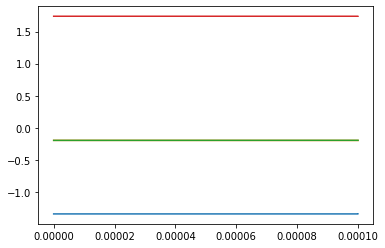

(3, 125000, 4)
dF:  (125000, 4, 3)
ddF:  (125000, 4, 3, 3)


In [ ]:
path="C:/Users/neb16/Documents/Uni/PHD/Experiments/Simulations/Spin_Hamiltonian/spin_hamiltonian/ion_params/"
gnd="Yb_CaWO.yml"
ground=spin.hamilFromYAML(path+gnd)

pts=50
r=1E-4
r,thetas,phis=np.meshgrid(np.linspace(0,1E-4),np.linspace(0,np.pi,pts),np.linspace(0,2*np.pi,pts))
x=(r*np.sin(thetas)*np.cos(phis)).flatten()
y=(r*np.sin(thetas)*np.sin(phis)).flatten()
z=(r*np.cos(thetas)).flatten()
vec=np.vstack([x,y,z])
Bs=vec
print("\n")
print("Bs: ", Bs.shape)

HD=ground.dynamicH(Bs,static=True)
# HD=np.rollaxis(HD,-1,0)
# print("HD",HD.shape)
# H=np.array(ground.H)[np.newaxis,...]+HD
H=HD
print("dH",ground.dH.shape)

print("H: ",H.shape)
F,V=ground.getEigFreq(H)
#print(gr)
print("F: ", F.shape)
print("V: ", V.shape)


#This is a reasonable shape for easy plotting
plt.plot(np.linalg.norm(Bs,axis=0),F)
plt.show()

Fp=ground.firstDerivative(V)
print("dF: ",Fp.shape)
Fpp=ground.curvatureCalculation(V,F)
print("ddF: ",Fpp.shape)
